# PM2.5 Prediction Using Neural Network Model (scikit-learn)

**Optimized with Optuna + TimeSeriesSplit Cross-Validation**

## 1. Setup & Data Loading

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
import joblib
import time

# For hyperparameter tuning
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances

# Setup paths
notebook_dir = Path.cwd()
if notebook_dir.name == 'notebooks':
    base_dir = notebook_dir.parent
else:
    base_dir = notebook_dir

output_dir = base_dir / 'preprocessed_data'
model_dir = base_dir / 'models'
model_dir.mkdir(exist_ok=True)

print(f"Base directory: {base_dir}")
print(f"Data directory: {output_dir}")
print(f"Model directory: {model_dir}")

Base directory: c:\Users\user\Desktop\3Y\S02\GP\project\pm25-air-quality
Data directory: c:\Users\user\Desktop\3Y\S02\GP\project\pm25-air-quality\preprocessed_data
Model directory: c:\Users\user\Desktop\3Y\S02\GP\project\pm25-air-quality\models


In [14]:
# Load preprocessed data
X_train = pd.read_csv(output_dir / 'X_train.csv')
y_train = pd.read_csv(output_dir / 'y_train.csv').squeeze()
X_val = pd.read_csv(output_dir / 'X_val.csv')
y_val = pd.read_csv(output_dir / 'y_val.csv').squeeze()
X_test = pd.read_csv(output_dir / 'X_test.csv')
y_test = pd.read_csv(output_dir / 'y_test.csv').squeeze()

# Enforce final optimized feature set
final_features = [
    'latitude', 'longitude', 'year',
    'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    'temperature_celsius', 'pressure_mb', 'wind_u', 'wind_v', 'wind_magnitude',
    'NO2', 'CO', 'O3', 'AOD', 'pollution_index',
    'pm25_lag1', 'temp_lag1', 'pollution_lag1',
    'aod_pollution_interaction', 'temp_pollution_interaction',
    'pressure_pollution_interaction', 'temp_pressure_interaction'
]

# Filter to available features to avoid potential missing column errors
final_features = [f for f in final_features if f in X_train.columns]


X_train = X_train[final_features]
X_val = X_val[final_features]
X_test = X_test[final_features]




# Load scaling config
scaling_config = joblib.load(output_dir / 'scaling_config.pkl')

print(f"Training set:   {X_train.shape[0]:>6,} samples, {X_train.shape[1]} features")
print(f"Validation set: {X_val.shape[0]:>6,} samples, {X_val.shape[1]} features")
print(f"Test set:       {X_test.shape[0]:>6,} samples, {X_test.shape[1]} features")

print(f"\nFeatures: {list(X_train.columns)}")

# Data verification
print(f"\n{'='*80}")
print("DATA VERIFICATION")
print(f"{'='*80}")

print(f"\nFeature scaling check:")
print(f"  X_train mean: {X_train.mean().mean():.4f}, std: {X_train.std().mean():.4f}")
print(f"  X_val mean:   {X_val.mean().mean():.4f}, std: {X_val.std().mean():.4f}")
print(f"  X_test mean:  {X_test.mean().mean():.4f}, std: {X_test.std().mean():.4f}")

print(f"\nMissing values check:")
print(f"  X_train: {X_train.isnull().sum().sum()} missing")
print(f"  X_val:   {X_val.isnull().sum().sum()} missing")
print(f"  X_test:  {X_test.isnull().sum().sum()} missing")
print(f"  y_train: {y_train.isnull().sum()} missing")
print(f"  y_val:   {y_val.isnull().sum()} missing")
print(f"  y_test:  {y_test.isnull().sum()} missing")

print(f"\nTarget (pm25) statistics:")
print(f"  Train — mean: {y_train.mean():.2f}, std: {y_train.std():.2f}, range: [{y_train.min():.2f}, {y_train.max():.2f}]")
print(f"  Val   — mean: {y_val.mean():.2f}, std: {y_val.std():.2f}, range: [{y_val.min():.2f}, {y_val.max():.2f}]")
print(f"  Test  — mean: {y_test.mean():.2f}, std: {y_test.std():.2f}, range: [{y_test.min():.2f}, {y_test.max():.2f}]")

# Check for outliers
print(f"\nOutlier check (values > 200 μg/m³):")
print(f"  Train: {(y_train > 200).sum()} outliers ({(y_train > 200).sum() / len(y_train) * 100:.2f}%)")
print(f"  Val:   {(y_val > 200).sum()} outliers ({(y_val > 200).sum() / len(y_val) * 100:.2f}%)")
print(f"  Test:  {(y_test > 200).sum()} outliers ({(y_test > 200).sum() / len(y_test) * 100:.2f}%)")
print(f"\n ")

Training set:   29,011 samples, 24 features
Validation set:  4,144 samples, 24 features
Test set:        8,290 samples, 24 features

Features: ['latitude', 'longitude', 'year', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'temperature_celsius', 'pressure_mb', 'wind_u', 'wind_v', 'wind_magnitude', 'NO2', 'CO', 'O3', 'AOD', 'pollution_index', 'pm25_lag1', 'temp_lag1', 'pollution_lag1', 'aod_pollution_interaction', 'temp_pollution_interaction', 'pressure_pollution_interaction', 'temp_pressure_interaction']

DATA VERIFICATION

Feature scaling check:
  X_train mean: 87.7828, std: 2.4195
  X_val mean:   87.5391, std: 1.8140
  X_test mean:  88.0647, std: 1.7172

Missing values check:
  X_train: 0 missing
  X_val:   0 missing
  X_test:  0 missing
  y_train: 0 missing
  y_val:   0 missing
  y_test:  0 missing

Target (pm25) statistics:
  Train — mean: 9.31, std: 17.27, range: [0.00, 1000.00]
  Val   — mean: 10.18, std: 11.98, range: [0.00, 508.18]
  Test  — mean: 9.89, std: 7.21, range: [0.0

``Note:`` 
- Outliers should be handled or removed in preprocessing for better model performance(we'll keep them for now but more investigation regarding them is needed)
- Selected only the needed features but this should be moved to the preprocessing notebook

## 2. Evaluation Metrics Function

In [15]:
def compute_metrics(y_true, y_pred, set_name=""):
    """Compute comprehensive regression metrics."""
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    
    metrics = {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
    }
    
    if set_name:
        print(f"{set_name} Set:")
        print(f"  MSE:  {mse:.4f}")
        print(f"  RMSE: {rmse:.4f} μg/m³")
        print(f"  MAE:  {mae:.4f} μg/m³")
        print(f"  R²:   {r2:.4f}")
    
    return metrics

print("Metrics function defined")

Metrics function defined


## 3. Hyperparameter Tuning with Optuna + TimeSeriesSplit

We'll use Optuna to find optimal hyperparameters using TimeSeriesSplit cross-validation on the training set.

In [13]:
# Optuna objective function
def objective(trial):
    """
    Optuna objective function for hyperparameter optimization.
    Uses TimeSeriesSplit CV on training data.
    """
    
    # Suggest hyperparameters
    hidden_layer_1 = trial.suggest_int('hidden_layer_1', 64, 256, step=32)
    hidden_layer_2 = trial.suggest_int('hidden_layer_2', 32, 128, step=16)
    hidden_layer_3 = trial.suggest_int('hidden_layer_3', 16, 64, step=16)
    
    activation = trial.suggest_categorical('activation', ['relu', 'tanh'])
    alpha = trial.suggest_float('alpha', 1e-5, 1e-2, log=True)
    learning_rate_init = trial.suggest_float('learning_rate_init', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [64, 128, 256])
    
    # Create model with suggested hyperparameters
    model = MLPRegressor(
        hidden_layer_sizes=(hidden_layer_1, hidden_layer_2, hidden_layer_3),
        activation=activation,
        solver='adam',
        alpha=alpha,
        batch_size=batch_size,
        learning_rate='adaptive',
        learning_rate_init=learning_rate_init,
        max_iter=200,  # Reduced for faster tuning
        early_stopping=False,  # We'll use CV for validation
        random_state=42,
        verbose=False
    )
    
    # TimeSeriesSplit cross-validation
    tscv = TimeSeriesSplit(n_splits=5)
    cv_scores = []
    
    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
        X_fold_train = X_train.iloc[train_idx]
        y_fold_train = y_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]
        y_fold_val = y_train.iloc[val_idx]
        
        # Train on fold
        model.fit(X_fold_train, y_fold_train)
        
        # Evaluate on validation fold
        y_fold_pred = model.predict(X_fold_val)
        fold_rmse = np.sqrt(mean_squared_error(y_fold_val, y_fold_pred))
        cv_scores.append(fold_rmse)
    
    # Return mean CV RMSE (lower is better)
    mean_cv_rmse = np.mean(cv_scores)
    
    return mean_cv_rmse

print("Optuna objective function defined")
print("\nThis will perform TimeSeriesSplit CV (5 folds) for each trial")
print("Optimization metric: Mean CV RMSE (lower is better)")

Optuna objective function defined

This will perform TimeSeriesSplit CV (5 folds) for each trial
Optimization metric: Mean CV RMSE (lower is better)


In [14]:
# Create and run Optuna study
print(f"{'='*80}")
print("HYPERPARAMETER OPTIMIZATION WITH OPTUNA")
print(f"{'='*80}")
print(f"\nSearching for optimal hyperparameters...")
print(f"This may take time depending on n_trials\n")

# Create study
study = optuna.create_study(
    direction='minimize',  # Minimize RMSE
    study_name='mlp_pm25_optimization',
    sampler=optuna.samplers.TPESampler(seed=42)
)

# Run optimization
N_TRIALS = 10
start_time = time.time()

study.optimize(
    objective, 
    n_trials=N_TRIALS,
    show_progress_bar=True,
    n_jobs=1  
)

elapsed = time.time() - start_time

print(f"\n{'='*80}")
print(f"OPTIMIZATION COMPLETE")
print(f"{'='*80}")
print(f"Time elapsed: {elapsed:.1f}s ({elapsed/60:.1f} min)")
print(f"Number of trials: {len(study.trials)}")
print(f"\nBest trial:")
print(f"  Value (CV RMSE): {study.best_value:.4f} μg/m³")
print(f"  Params:")
for key, value in study.best_params.items():
    print(f"    {key}: {value}")

# Save study
joblib.dump(study, model_dir / 'optuna_study.pkl')
print(f"\nStudy saved to {model_dir / 'optuna_study.pkl'}")


[I 2026-04-19 00:39:12,225] A new study created in memory with name: mlp_pm25_optimization


HYPERPARAMETER OPTIMIZATION WITH OPTUNA

Searching for optimal hyperparameters...
This may take time depending on n_trials



Best trial: 0. Best value: 14.8591:  10%|█         | 1/10 [02:34<23:09, 154.37s/it]

[I 2026-04-19 00:41:46,626] Trial 0 finished with value: 14.859056871203176 and parameters: {'hidden_layer_1': 128, 'hidden_layer_2': 128, 'hidden_layer_3': 48, 'activation': 'relu', 'alpha': 2.9375384576328295e-05, 'learning_rate_init': 0.00013066739238053285, 'batch_size': 64}. Best is trial 0 with value: 14.859056871203176.


Best trial: 0. Best value: 14.8591:  20%|██        | 2/10 [04:21<16:51, 126.49s/it]

...

[I 2026-04-19 00:57:08,726] Trial 7 finished with value: 14.710084140579884 and parameters: {'hidden_layer_1': 224, 'hidden_layer_2': 48, 'hidden_layer_3': 16, 'activation': 'relu', 'alpha': 0.0015382308040279, 'learning_rate_init': 0.0034877126245459306, 'batch_size': 128}. Best is trial 2 with value: 13.901392717576504.


Best trial: 2. Best value: 13.9014:  90%|█████████ | 9/10 [20:06<01:43, 103.90s/it]

[I 2026-04-19 00:59:18,619] Trial 8 finished with value: 14.763834387365412 and parameters: {'hidden_layer_1': 256, 'hidden_layer_2': 96, 'hidden_layer_3': 32, 'activation': 'tanh', 'alpha': 9.452571391072311e-05, 'learning_rate_init': 0.002878805718308925, 'batch_size': 128}. Best is trial 2 with value: 13.901392717576504.


Best trial: 2. Best value: 13.9014: 100%|██████████| 10/10 [20:47<00:00, 124.74s/it]

[I 2026-04-19 00:59:59,674] Trial 9 finished with value: 14.762091351270772 and parameters: {'hidden_layer_1': 64, 'hidden_layer_2': 96, 'hidden_layer_3': 64, 'activation': 'tanh', 'alpha': 0.00030296104428212476, 'learning_rate_init': 0.0011103647313054626, 'batch_size': 64}. Best is trial 2 with value: 13.901392717576504.

OPTIMIZATION COMPLETE
Time elapsed: 1247.5s (20.8 min)
Number of trials: 10

Best trial:
  Value (CV RMSE): 13.9014 μg/m³
  Params:
    hidden_layer_1: 192
    hidden_layer_2: 32
    hidden_layer_3: 32
    activation: tanh
    alpha: 0.0022673986523780395
    learning_rate_init: 0.00025081156860452336
    batch_size: 128

Study saved to c:\Users\user\Desktop\3Y\S02\GP\project\pm25-air-quality\models\optuna_study.pkl


In [ ]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Optimization history
optuna.visualization.matplotlib.plot_optimization_history(study, ax=axes[0])
axes[0].set_title('Optimization History', fontsize=14, fontweight='bold')
axes[0].set_ylabel('CV RMSE (μg/m³)', fontsize=12)

# Parameter importances
optuna.visualization.matplotlib.plot_param_importances(study, ax=axes[1])
axes[1].set_title('Hyperparameter Importances', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(model_dir / 'optuna_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

print("Optimization visualizations saved")


## 4. Train Final Model with Best Hyperparameters

### Alternative: Train Quick Model with Basic Parameters
Run this cell if you want to skip the hyperparameter tuning process above.
(this would be removed later once the best parameters are found)

In [6]:
print(f"{'='*80}")
print("TRAINING MODEL WITH BASIC HYPERPARAMETERS")
print(f"{'='*80}")

# Create model with sensible default parameters
basic_model = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,
    batch_size=128,
    learning_rate='adaptive',
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    tol=1e-5,
    random_state=42,
    verbose=True
)

print("\nModel architecture:")
print("  Hidden layers: (128, 64, 32)")
print("  Activation: relu")
print("  Alpha (L2): 0.001")
print("  Learning rate: 0.001")
print("  Batch size: 128")

print(f"\n{'='*60}")
print("Starting training on full training set...")
print(f"{'='*60}\n")

start_time = time.time()
basic_model.fit(X_train, y_train)
elapsed = time.time() - start_time

print(f"\n{'='*60}")
print(f"Training complete in {elapsed:.1f}s ({elapsed/60:.1f} min)")
print(f"Iterations: {basic_model.n_iter_}")
print(f"Best validation score: {basic_model.best_validation_score_:.4f}")
print(f"Final training loss: {basic_model.loss_:.6f}")
print(f"{'='*60}")

# Map to final_model so down-stream evaluation cells work properly!
final_model = basic_model


TRAINING MODEL WITH BASIC HYPERPARAMETERS

Model architecture:
  Hidden layers: (128, 64, 32)
  Activation: relu
  Alpha (L2): 0.001
  Learning rate: 0.001
  Batch size: 128

Starting training on full training set...

Iteration 1, loss = 168.65417049
Validation score: -0.932561
Iteration 2, loss = 125.07764049
Validation score: -0.295308
Iteration 3, loss = 115.34306883
Validation score: -0.769417
Iteration 4, loss = 110.96222489
Validation score: -0.414426
Iteration 5, loss = 115.42945189
Validation score: -0.699547
Iteration 6, loss = 109.52898777
Validation score: -0.684146
Iteration 7, loss = 110.76573625
Validation score: -1.041701
Iteration 8, loss = 110.79574754
Validation score: -0.963819
Iteration 9, loss = 106.66237360
Validation score: -0.576452
Iteration 10, loss = 109.46854868
Validation score: -0.791865
Iteration 11, loss = 110.83277693
Validation score: -0.813863
Iteration 12, loss = 108.57732007
Validation score: -0.868930
Iteration 13, loss = 107.55774283
Validation sc

## This uses optuna results

- Run this to load the optuna results

In [16]:
study = joblib.load('../models/optuna_study.pkl')
best_params = study.best_params 


In [17]:
# Extract best hyperparameters
best_params = study.best_params

print(f"{'='*80}")
print("TRAINING FINAL MODEL WITH BEST HYPERPARAMETERS")
print(f"{'='*80}")

# Create final model
final_model = MLPRegressor(
    hidden_layer_sizes=(
        best_params['hidden_layer_1'],
        best_params['hidden_layer_2'],
        best_params['hidden_layer_3']
    ),
    activation=best_params['activation'],
    solver='adam',
    alpha=best_params['alpha'],
    batch_size=best_params['batch_size'],
    learning_rate='adaptive',
    learning_rate_init=best_params['learning_rate_init'],
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    tol=1e-5,
    random_state=42,
    verbose=True
)

print(f"\nModel architecture:")
print(f"  Hidden layers: ({best_params['hidden_layer_1']}, {best_params['hidden_layer_2']}, {best_params['hidden_layer_3']})")
print(f"  Activation: {best_params['activation']}")
print(f"  Alpha (L2): {best_params['alpha']:.6f}")
print(f"  Learning rate: {best_params['learning_rate_init']:.6f}")
print(f"  Batch size: {best_params['batch_size']}")

print(f"\n{'='*60}")
print("Starting training on full training set...")
print(f"{'='*60}\n")

start_time = time.time()
final_model.fit(X_train, y_train)
elapsed = time.time() - start_time

print(f"\n{'='*60}")
print(f"Training complete in {elapsed:.1f}s ({elapsed/60:.1f} min)")
print(f"Iterations: {final_model.n_iter_}")
print(f"Best validation score: {final_model.best_validation_score_:.4f}")
print(f"Final training loss: {final_model.loss_:.6f}")
print(f"{'='*60}")


TRAINING FINAL MODEL WITH BEST HYPERPARAMETERS

Model architecture:
  Hidden layers: (192, 32, 32)
  Activation: tanh
  Alpha (L2): 0.002267
  Learning rate: 0.000251
  Batch size: 128

Starting training on full training set...

Iteration 1, loss = 163.92279392
Validation score: -0.034295
Iteration 2, loss = 155.27187437
Validation score: -0.008738
Iteration 3, loss = 153.71662736
Validation score: -0.002126
Iteration 4, loss = 153.26952451
Validation score: 0.001657
Iteration 5, loss = 150.89807499
Validation score: -0.001546
Iteration 6, loss = 152.55113544
Validation score: 0.022547
Iteration 7, loss = 148.93311593
Validation score: -0.010968
Iteration 8, loss = 150.54591431
Validation score: 0.026681
Iteration 9, loss = 146.45024241
Validation score: 0.064967
Iteration 10, loss = 144.61225533
Validation score: 0.070891
Iteration 11, loss = 144.19843048
Validation score: 0.076930
Iteration 12, loss = 143.42936162
Validation score: 0.077938
Iteration 13, loss = 143.16548554
Validatio

## 5. Model Evaluation on All Splits

In [18]:
#Generate predictions
train_pred = final_model.predict(X_train)
val_pred = final_model.predict(X_val)
test_pred = final_model.predict(X_test)

print(f"{'='*80}")
print("MODEL EVALUATION RESULTS")
print(f"{'='*80}\n")

results = {}
results['Train'] = compute_metrics(y_train.values, train_pred, "Train")
print()
results['Validation'] = compute_metrics(y_val.values, val_pred, "Validation")
print()
results['Test'] = compute_metrics(y_test.values, test_pred, "Test")

results_df = pd.DataFrame(results).T
print(f"\n{'='*80}")
print("\nSummary Table:")
print(results_df.to_string())
print(f"\n{'='*80}")

print("\nPerformance Check:")
if results['Train']['R²'] > results['Validation']['R²'] > results['Test']['R²']:
    print("GOOD: Train R² > Val R² > Test R² (expected pattern)")
elif results['Train']['R²'] > results['Test']['R²'] and results['Validation']['R²'] > results['Test']['R²']:
    print("OK: Train & Val R² > Test R² (acceptable)")
else:
    print(f"WARNING: Unexpected R² pattern")
    print(f"Train: {results['Train']['R²']:.4f}, Validation: {results['Validation']['R²']:.4f}, Test: {results['Test']['R²']:.4f}")


MODEL EVALUATION RESULTS

Train Set:
  MSE:  254.7100
  RMSE: 15.9596 μg/m³
  MAE:  3.5538 μg/m³
  R²:   0.1461

Validation Set:
  MSE:  123.8045
  RMSE: 11.1267 μg/m³
  MAE:  4.2623 μg/m³
  R²:   0.1371

Test Set:
  MSE:  28.1445
  RMSE: 5.3051 μg/m³
  MAE:  3.4390 μg/m³
  R²:   0.4589


Summary Table:
                   MSE       RMSE       MAE        R²
Train       254.710048  15.959638  3.553779  0.146140
Validation  123.804483  11.126746  4.262275  0.137093
Test         28.144505   5.305140  3.438983  0.458861


Performance Check:
Train: 0.1461, Validation: 0.1371, Test: 0.4589


## 6. Prediction Visualizations

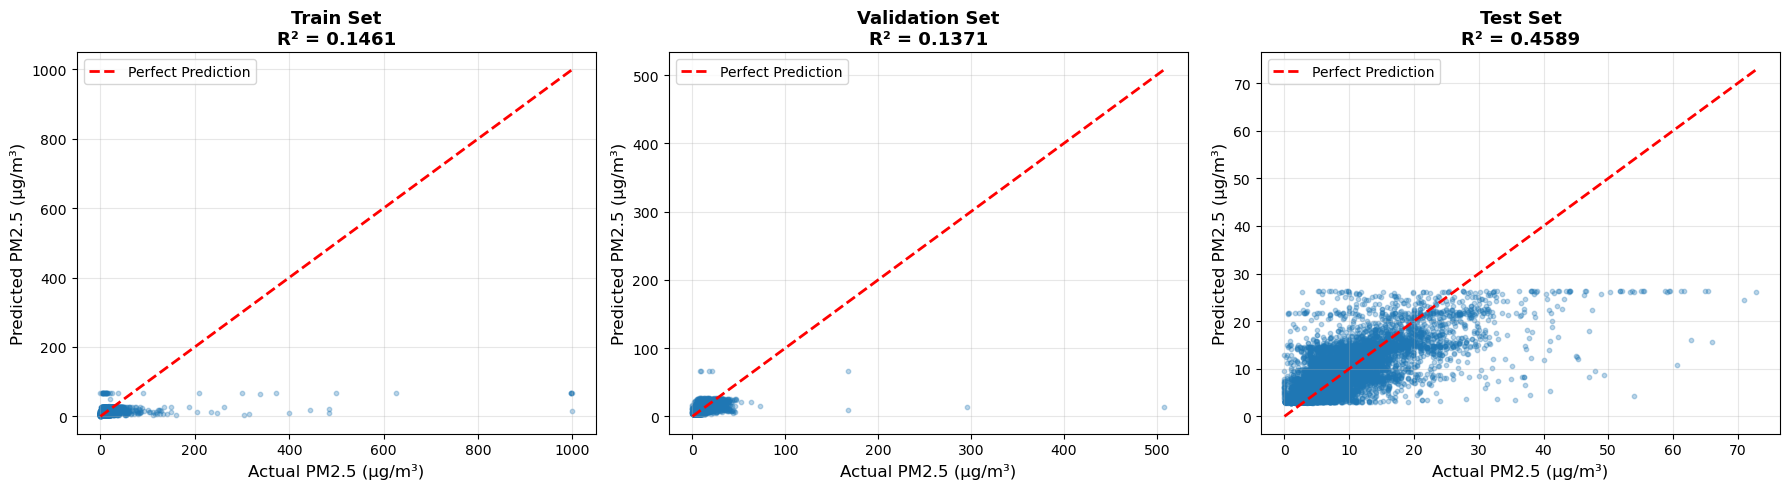

In [19]:
# Actual vs Predicted
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, y_true, y_pred) in enumerate([
    ('Train', y_train.values, train_pred),
    ('Validation', y_val.values, val_pred),
    ('Test', y_test.values, test_pred)
]):
    ax = axes[idx]
    ax.scatter(y_true, y_pred, alpha=0.3, s=10)
    
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
    
    ax.set_xlabel('Actual PM2.5 (μg/m³)', fontsize=12)
    ax.set_ylabel('Predicted PM2.5 (μg/m³)', fontsize=12)
    ax.set_title(f'{name} Set\nR² = {results[name]["R²"]:.4f}', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(model_dir / 'predictions_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


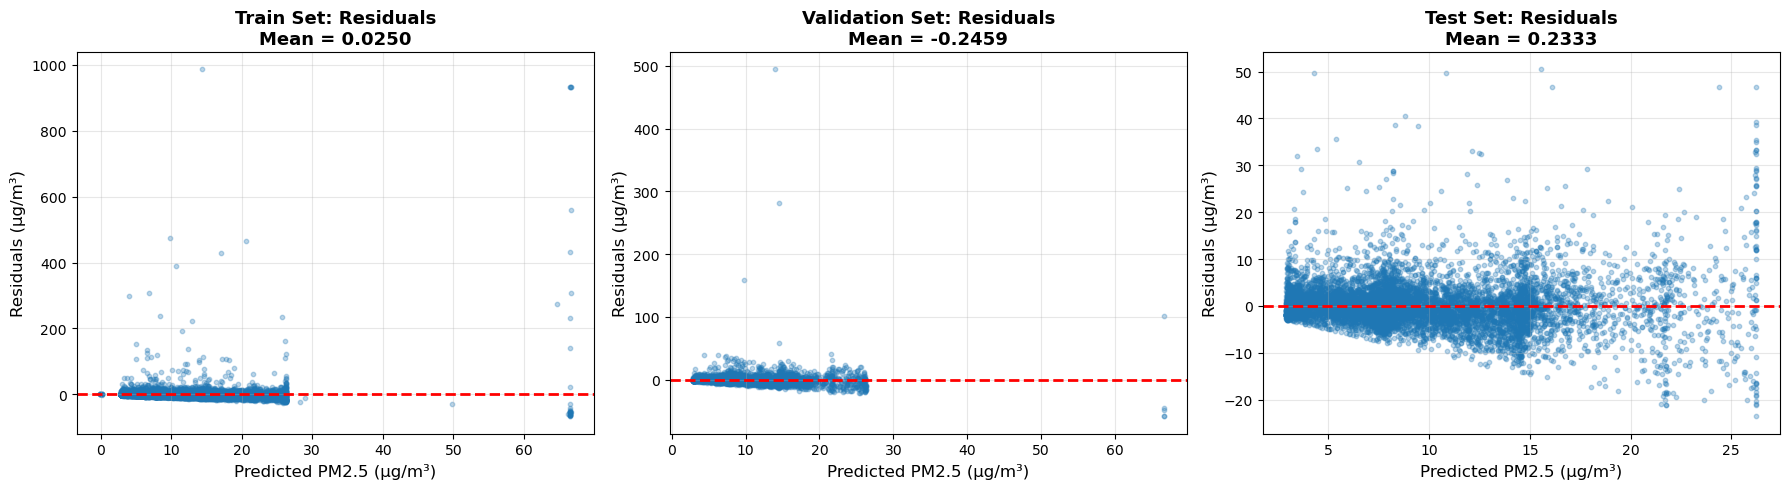

In [20]:
# Residual plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, y_true, y_pred) in enumerate([
    ('Train', y_train.values, train_pred),
    ('Validation', y_val.values, val_pred),
    ('Test', y_test.values, test_pred)
]):
    ax = axes[idx]
    residuals = y_true - y_pred
    
    ax.scatter(y_pred, residuals, alpha=0.3, s=10)
    ax.axhline(y=0, color='r', linestyle='--', lw=2)
    
    ax.set_xlabel('Predicted PM2.5 (μg/m³)', fontsize=12)
    ax.set_ylabel('Residuals (μg/m³)', fontsize=12)
    ax.set_title(f'{name} Set: Residuals\nMean = {residuals.mean():.4f}', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(model_dir / 'residuals.png', dpi=150, bbox_inches='tight')
plt.show()


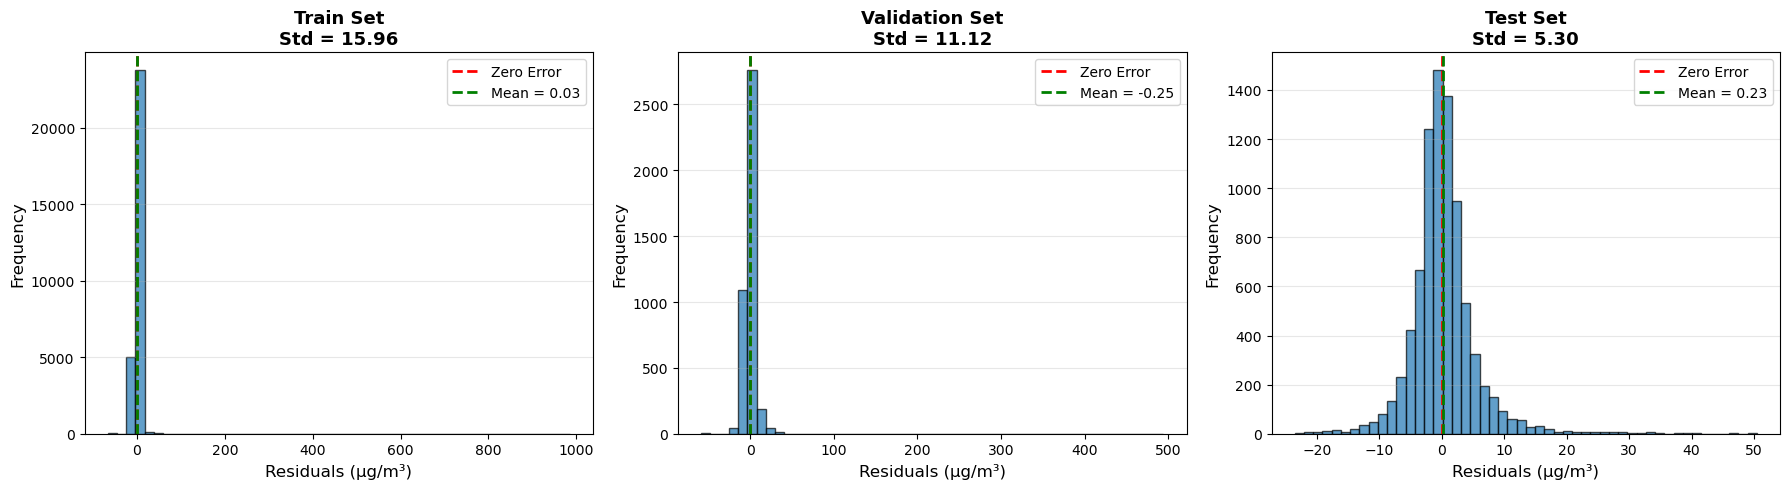

In [21]:
# Error distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, y_true, y_pred) in enumerate([
    ('Train', y_train.values, train_pred),
    ('Validation', y_val.values, val_pred),
    ('Test', y_test.values, test_pred)
]):
    ax = axes[idx]
    residuals = y_true - y_pred
    
    ax.hist(residuals, bins=50, edgecolor='black', alpha=0.7)
    ax.axvline(x=0, color='r', linestyle='--', lw=2, label='Zero Error')
    ax.axvline(x=residuals.mean(), color='g', linestyle='--', lw=2, label=f'Mean = {residuals.mean():.2f}')
    
    ax.set_xlabel('Residuals (μg/m³)', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title(f'{name} Set\nStd = {residuals.std():.2f}', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(model_dir / 'error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Final Cross-Validation Assessment

### Alternative: Final CV with Basic Parameters
Run this cell to perform the 5-fold TimeSeries split evaluation using the standard baseline parameters(will be removed later)

In [8]:
# Final CV with basic params
print(f"{'='*80}")
print("FINAL CROSS-VALIDATION WITH BASIC HYPERPARAMETERS")
print(f"{'='*80}")
print("\nPerforming TimeSeriesSplit CV (5 folds)...\n")

from sklearn.model_selection import TimeSeriesSplit
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

tscv = TimeSeriesSplit(n_splits=5)
cv_results = {
    'fold': [], 'train_size': [], 'val_size': [],
    'train_r2': [], 'val_r2': [], 'train_rmse': [], 'val_rmse': [],
    'train_mae': [], 'val_mae': []
}

for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train), 1):
    X_fold_train = X_train.iloc[train_idx]
    y_fold_train = y_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]
    y_fold_val = y_train.iloc[val_idx]
    
    # Using hardcoded basic parameters
    fold_model = MLPRegressor(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        solver='adam',
        alpha=0.001,
        batch_size=128,
        learning_rate='adaptive',
        learning_rate_init=0.001,
        max_iter=200,
        early_stopping=False,
        random_state=42,
        verbose=False
    )
    
    fold_model.fit(X_fold_train, y_fold_train)
    
    train_pred_fold = fold_model.predict(X_fold_train)
    val_pred_fold = fold_model.predict(X_fold_val)
    
    train_r2 = r2_score(y_fold_train, train_pred_fold)
    val_r2 = r2_score(y_fold_val, val_pred_fold)
    train_rmse = np.sqrt(mean_squared_error(y_fold_train, train_pred_fold))
    val_rmse = np.sqrt(mean_squared_error(y_fold_val, val_pred_fold))
    train_mae = mean_absolute_error(y_fold_train, train_pred_fold)
    val_mae = mean_absolute_error(y_fold_val, val_pred_fold)
    
    cv_results['fold'].append(fold_idx)
    cv_results['train_size'].append(len(train_idx))
    cv_results['val_size'].append(len(val_idx))
    cv_results['train_r2'].append(train_r2)
    cv_results['val_r2'].append(val_r2)
    cv_results['train_rmse'].append(train_rmse)
    cv_results['val_rmse'].append(val_rmse)
    cv_results['train_mae'].append(train_mae)
    cv_results['val_mae'].append(val_mae)
    
    print(f"Fold {fold_idx}:")
    print(f"  Train: {len(train_idx):>6} samples | R²={train_r2:>6.4f} | RMSE={train_rmse:>7.4f} | MAE={train_mae:>6.4f}")
    print(f"  Val:   {len(val_idx):>6} samples | R²={val_r2:>6.4f} | RMSE={val_rmse:>7.4f} | MAE={val_mae:>6.4f}")
    print()

cv_df = pd.DataFrame(cv_results)

print(f"{'='*80}")
print("CROSS-VALIDATION SUMMARY (BASIC MODEL)")
print(f"{'='*80}")
print(f"\nValidation Metrics (Mean ± Std):")
print(f"  R²:   {cv_df['val_r2'].mean():.4f} ± {cv_df['val_r2'].std():.4f}")
print(f"  RMSE: {cv_df['val_rmse'].mean():.4f} ± {cv_df['val_rmse'].std():.4f} μg/m³")
print(f"  MAE:  {cv_df['val_mae'].mean():.4f} ± {cv_df['val_mae'].std():.4f} μg/m³")

print(f"\nStability Check:")
if cv_df['val_r2'].std() < 0.1:
    print(f"GOOD: Low variance (std = {cv_df['val_r2'].std():.4f})")
else:
    print(f"WARNING: High variance (std = {cv_df['val_r2'].std():.4f})")

cv_df.to_csv(model_dir / 'cv_results.csv', index=False)
print(f"\nCV results saved")


FINAL CROSS-VALIDATION WITH BASIC HYPERPARAMETERS

Performing TimeSeriesSplit CV (5 folds)...

Fold 1:
  Train:   4836 samples | R²=0.4125 | RMSE= 5.8473 | MAE=3.9747
  Val:     4835 samples | R²=-0.0111 | RMSE= 7.6699 | MAE=4.3580

Fold 2:
  Train:   9671 samples | R²=0.3767 | RMSE= 6.0401 | MAE=3.2338
  Val:     4835 samples | R²=-0.0161 | RMSE=35.1751 | MAE=6.1039

Fold 3:
  Train:  14506 samples | R²=0.3894 | RMSE=16.5285 | MAE=4.1192
  Val:     4835 samples | R²=0.3142 | RMSE= 4.9625 | MAE=3.0664

Fold 4:
  Train:  19341 samples | R²=0.4233 | RMSE=14.0962 | MAE=3.6699
  Val:     4835 samples | R²=0.3973 | RMSE= 5.4926 | MAE=3.4597

Fold 5:
  Train:  24176 samples | R²=0.4063 | RMSE=13.0293 | MAE=3.5478
  Val:     4835 samples | R²=-0.3942 | RMSE=22.4067 | MAE=3.8188

CROSS-VALIDATION SUMMARY (BASIC MODEL)

Validation Metrics (Mean ± Std):
  R²:   0.0580 ± 0.3145
  RMSE: 15.1414 ± 13.2916 μg/m³
  MAE:  4.1614 ± 1.1854 μg/m³

Stability Check:

CV results saved


### This uses the best parameters found by optuna

In [22]:
# Final CV with best params
print(f"{'='*80}")
print("FINAL CROSS-VALIDATION WITH BEST HYPERPARAMETERS")
print(f"{'='*80}")
print("\nPerforming TimeSeriesSplit CV (5 folds)...\n")

tscv = TimeSeriesSplit(n_splits=5)
cv_results = {
    'fold': [], 'train_size': [], 'val_size': [],
    'train_r2': [], 'val_r2': [], 'train_rmse': [], 'val_rmse': [],
    'train_mae': [], 'val_mae': []
}

for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train), 1):
    X_fold_train = X_train.iloc[train_idx]
    y_fold_train = y_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]
    y_fold_val = y_train.iloc[val_idx]
    
    fold_model = MLPRegressor(
        hidden_layer_sizes=(best_params['hidden_layer_1'], best_params['hidden_layer_2'], best_params['hidden_layer_3']),
        activation=best_params['activation'],
        solver='adam',
        alpha=best_params['alpha'],
        batch_size=best_params['batch_size'],
        learning_rate='adaptive',
        learning_rate_init=best_params['learning_rate_init'],
        max_iter=200,
        early_stopping=False,
        random_state=42,
        verbose=False
    )
    
    fold_model.fit(X_fold_train, y_fold_train)
    
    train_pred_fold = fold_model.predict(X_fold_train)
    val_pred_fold = fold_model.predict(X_fold_val)
    
    train_r2 = r2_score(y_fold_train, train_pred_fold)
    val_r2 = r2_score(y_fold_val, val_pred_fold)
    train_rmse = np.sqrt(mean_squared_error(y_fold_train, train_pred_fold))
    val_rmse = np.sqrt(mean_squared_error(y_fold_val, val_pred_fold))
    train_mae = mean_absolute_error(y_fold_train, train_pred_fold)
    val_mae = mean_absolute_error(y_fold_val, val_pred_fold)
    
    cv_results['fold'].append(fold_idx)
    cv_results['train_size'].append(len(train_idx))
    cv_results['val_size'].append(len(val_idx))
    cv_results['train_r2'].append(train_r2)
    cv_results['val_r2'].append(val_r2)
    cv_results['train_rmse'].append(train_rmse)
    cv_results['val_rmse'].append(val_rmse)
    cv_results['train_mae'].append(train_mae)
    cv_results['val_mae'].append(val_mae)
    
    print(f"Fold {fold_idx}:")
    print(f"  Train: {len(train_idx):>6} samples | R²={train_r2:>6.4f} | RMSE={train_rmse:>7.4f} | MAE={train_mae:>6.4f}")
    print(f"  Val:   {len(val_idx):>6} samples | R²={val_r2:>6.4f} | RMSE={val_rmse:>7.4f} | MAE={val_mae:>6.4f}")
    print()

cv_df = pd.DataFrame(cv_results)

print(f"{'='*80}")
print("CROSS-VALIDATION SUMMARY")
print(f"{'='*80}")
print(f"\nValidation Metrics (Mean ± Std):")
print(f"  R²:   {cv_df['val_r2'].mean():.4f} ± {cv_df['val_r2'].std():.4f}")
print(f"  RMSE: {cv_df['val_rmse'].mean():.4f} ± {cv_df['val_rmse'].std():.4f} μg/m³")
print(f"  MAE:  {cv_df['val_mae'].mean():.4f} ± {cv_df['val_mae'].std():.4f} μg/m³")

print(f"\nStability Check:")
if cv_df['val_r2'].std() < 0.1:
    print(f"GOOD: Low variance (std = {cv_df['val_r2'].std():.4f})")
else:
    print(f"WARNING: High variance (std = {cv_df['val_r2'].std():.4f})")

cv_df.to_csv(model_dir / 'cv_results.csv', index=False)
print(f"\nCV results saved")


FINAL CROSS-VALIDATION WITH BEST HYPERPARAMETERS

Performing TimeSeriesSplit CV (5 folds)...

Fold 1:
  Train:   4836 samples | R²=0.6016 | RMSE= 4.8150 | MAE=3.0730
  Val:     4835 samples | R²=0.2606 | RMSE= 6.5589 | MAE=3.2561

Fold 2:
  Train:   9671 samples | R²=0.4617 | RMSE= 5.6132 | MAE=2.8364
  Val:     4835 samples | R²=0.0410 | RMSE=34.1727 | MAE=5.3418

Fold 3:
  Train:  14506 samples | R²=0.1248 | RMSE=19.7875 | MAE=3.9909
  Val:     4835 samples | R²=0.2717 | RMSE= 5.1139 | MAE=3.1777

Fold 4:
  Train:  19341 samples | R²=0.1291 | RMSE=17.3221 | MAE=3.6582
  Val:     4835 samples | R²=0.4503 | RMSE= 5.2454 | MAE=3.2410

Fold 5:
  Train:  24176 samples | R²=0.1491 | RMSE=15.5984 | MAE=3.6461
  Val:     4835 samples | R²=0.0582 | RMSE=18.4161 | MAE=3.4044

CROSS-VALIDATION SUMMARY

Validation Metrics (Mean ± Std):
  R²:   0.2164 ± 0.1700
  RMSE: 13.9014 ± 12.6231 μg/m³
  MAE:  3.6842 ± 0.9303 μg/m³

Stability Check:

CV results saved


# Feature importance

Calculating Permutation Feature Importance (this might take a few seconds)...


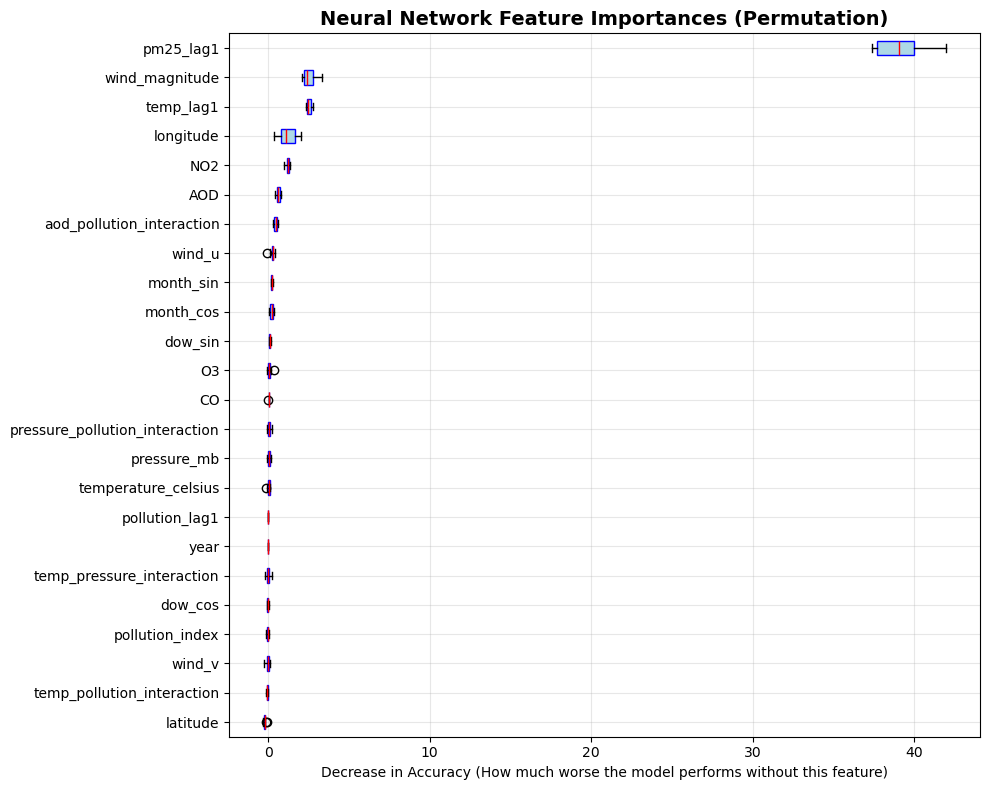

In [23]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import numpy as np

print("Calculating Permutation Feature Importance (this might take a few seconds)...")

# Calculate importance on the validation set
result = permutation_importance(
    final_model, 
    X_val, 
    y_val, 
    n_repeats=10,       # Shuffles each feature 10 times to get a stable average
    random_state=42, 
    n_jobs=-1,          # Uses all your CPU cores to make it fast
    scoring='neg_mean_squared_error' # We look at how much the error increases
)

# Sort the features by how important they are
sorted_idx = result.importances_mean.argsort()

# Create a nice plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.boxplot(
    result.importances[sorted_idx].T,
    vert=False,
    labels=X_val.columns[sorted_idx],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', color='blue'),
    medianprops=dict(color='red')
)

ax.set_title("Neural Network Feature Importances (Permutation)", fontsize=14, fontweight='bold')
ax.set_xlabel("Decrease in Accuracy (How much worse the model performs without this feature)")
ax.grid(True, alpha=0.3)
plt.tight_layout()

# Save and show
plt.savefig(model_dir / 'nn_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


- The result of the plot shows exactly why the neural network performance is not realy at its best since the pm25_lag1 dominates the other features and the models learned to use the previous value of the pm25_lag1 to predict the current one

In [24]:

# We use the 'result' object generated by the permutation_importance cell above.
mean_importances = result.importances_mean
# Some importances might be slightly negative due to random chance (meaning the model didn't use them). 
# We clip negatives to 0 so out percentages make mathematical sense.
positive_importances = np.maximum(mean_importances, 0)
# Calculate the percentages
total_importance = positive_importances.sum()
if total_importance > 0:
    percentages = (positive_importances / total_importance) * 100
else:
    percentages = np.zeros_like(positive_importances)
# Build a DataFrame for easy sorting and display
importance_df = pd.DataFrame({
    'Feature': X_val.columns,
    'Percentage (%)': percentages
})
# Sort from highest importance to lowest
importance_df = importance_df.sort_values(by='Percentage (%)', ascending=False).reset_index(drop=True)
# Print a nicely formatted table
print("FEATURE IMPORTANCE PERCENTAGES")
print("="*45)
for _, row in importance_df.iterrows():
    # Print out any feature that contributes at least 0.01%
    if row['Percentage (%)'] >= 0.01:
        print(f"{row['Feature']:<35} {row['Percentage (%)']:>6.2f}%")
print("="*45)
print(f"{'TOTAL':<35} 100.00%")

FEATURE IMPORTANCE PERCENTAGES
pm25_lag1                            80.35%
wind_magnitude                        5.23%
temp_lag1                             5.18%
longitude                             2.48%
NO2                                   2.47%
AOD                                   1.30%
aod_pollution_interaction             0.92%
wind_u                                0.53%
month_sin                             0.45%
month_cos                             0.42%
dow_sin                               0.20%
O3                                    0.14%
CO                                    0.11%
pressure_pollution_interaction        0.08%
pressure_mb                           0.07%
temperature_celsius                   0.06%
TOTAL                               100.00%


## 8. Save Model & Results

In [ ]:
# Save model
joblib.dump(final_model, model_dir / 'best_pm25_mlp_model.pkl')
print(f"Model saved to {model_dir / 'best_pm25_mlp_model.pkl'}")

# Save results
results_df.to_csv(model_dir / 'model_performance.csv')
print(f"Results saved to {model_dir / 'model_performance.csv'}")

# Model info
n_params = sum(w.size for w in final_model.coefs_) + sum(b.size for b in final_model.intercepts_)
print(f"\nModel Summary:")
print(f"  Total parameters: {n_params:,}")
print(f"  Architecture: {final_model.hidden_layer_sizes}")
print(f"  Best CV RMSE: {study.best_value:.4f} μg/m³")
print(f"  Test RMSE: {results['Test']['RMSE']:.4f} μg/m³")
print(f"  Test R²: {results['Test']['R²']:.4f}")
